# Credit Card Fraud Detection - End-to-End Machine Learning Pipeline

Welcome to this data science project! In this notebook, we will explore a credit card transactions dataset to predict whether a transaction is legitimate (0) or fraudulent (1). We will handle extreme class imbalance, perform exploratory data analysis, apply feature scaling, and build model pipelines using K-Nearest Neighbors (KNN) and XGBoost. Finally, we will use GridSearchCV and RandomizedSearchCV to optimize our classifiers.

## Q1. How do we load our dataset and get our first look at the data?

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Q2. What are the data types and where are the missing values?

In [2]:
# Get structural information and data types
df.info()

# Count total missing values in the dataset
print("\nTotal Missing Values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Q3. Understanding the Target: What is the distribution of the target variable `Class` (extreme class imbalance)?

Class Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%


C:\Users\GFG\AppData\Local\Temp\ipykernel_3136\2594537922.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#2196F3', '#F44336'])


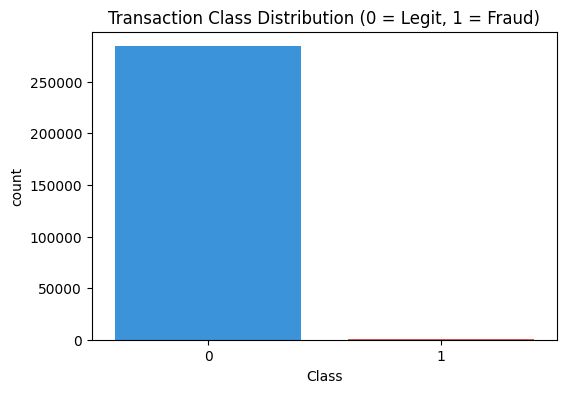

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count legitimate vs fraudulent transactions
class_counts = df['Class'].value_counts()
print("Class Counts:")
print(class_counts)

# Calculate the percentage of fraud
fraud_pct = (class_counts[1] / len(df)) * 100
print(f"\nFraud Percentage: {fraud_pct:.4f}%")

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#2196F3', '#F44336'])
plt.title('Transaction Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()

## Q4. EDA: How do transaction amounts compare between legitimate and fraudulent transactions?

In [4]:
# Separate transactions by class
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

print("=== Legitimate Transaction Amount Stats ===")
print(legit['Amount'].describe())

print("\n=== Fraudulent Transaction Amount Stats ===")
print(fraud['Amount'].describe())

=== Legitimate Transaction Amount Stats ===
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

=== Fraudulent Transaction Amount Stats ===
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


## Q5. EDA: Does the transaction `Time` reveal any patterns between legitimate and fraudulent transactions?

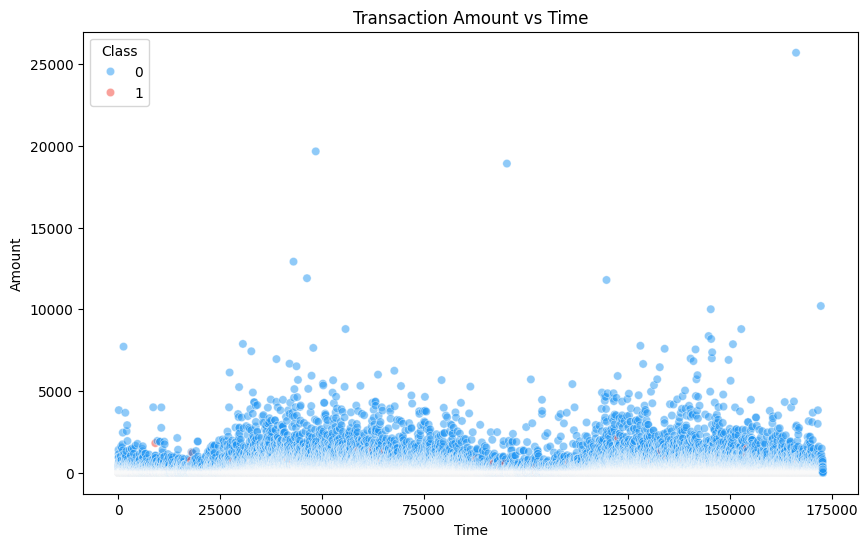

In [5]:
# Plot transaction Time vs Amount colored by target Class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.5, palette=['#2196F3', '#F44336'])
plt.title('Transaction Amount vs Time')
plt.show()

## Q6. EDA: What are the correlations between different features and the target variable `Class`?

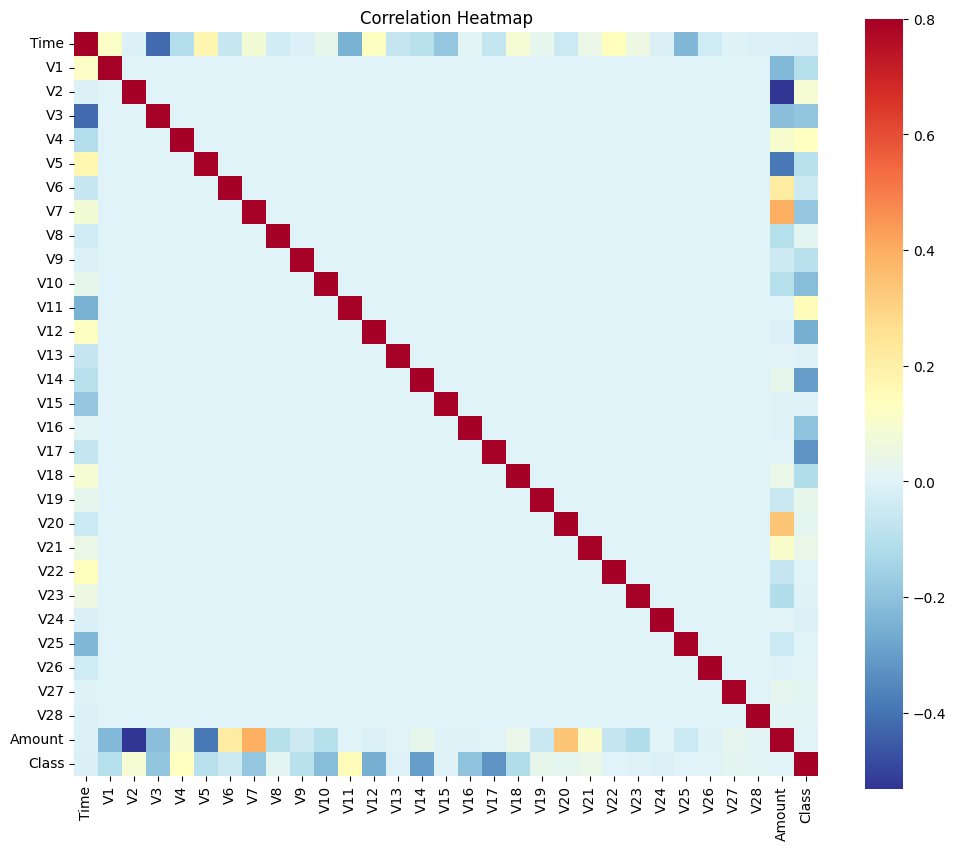

In [6]:
# Compute correlation matrix
corrmat = df.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corrmat, cmap='RdYlBu_r', annot=False, vmax=0.8, square=True)
plt.title('Correlation Heatmap')
plt.show()

## Q7. Splitting the Data: How do we split the dataset into training and testing sets while preserving class proportions?

In [7]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified 80/20 train/test split to preserve imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train set size: {X_train.shape[0]:,} samples")
print(f"Test set size:  {X_test.shape[0]:,} samples")

Train set size: 227,845 samples
Test set size:  56,962 samples


## Q8. Preprocessing: Why and how do we scale our numerical features?

In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale training and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing scale check:")
print("Mean of first feature:", X_train_scaled[:, 0].mean().round(6))
print("Std of first feature:", X_train_scaled[:, 0].std().round(6))

Preprocessing scale check:
Mean of first feature: -0.0
Std of first feature: 1.0


## Q9. Model Training: How do we train a baseline K-Nearest Neighbors (KNN) model on a subset of the data?

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# KNN can be very slow to execute on the full dataset, so we train it on a 10% stratified sample
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, y_train, 
    train_size=0.1, 
    random_state=42, 
    stratify=y_train
)

# Initialize and train distance-weighted KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn.fit(X_train_sample, y_train_sample)
print("KNN model trained successfully!")

KNN model trained successfully!


## Q10. Model Evaluation: How do we evaluate our KNN model on accuracy, precision, recall, and confusion matrix?

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on test set
y_pred_knn = knn.predict(X_test_scaled)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Legitimate', 'Fraud']))

Accuracy:  0.9994
Precision: 0.8427
Recall:    0.7653
F1-Score:  0.8021

Confusion Matrix:
[[56850    14]
 [   23    75]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.84      0.77      0.80        98

    accuracy                           1.00     56962
   macro avg       0.92      0.88      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## Q11. Model Training: How do we train an XGBoost Classifier that accounts for the class imbalance?

In [11]:
from xgboost import XGBClassifier

# Calculate class imbalance ratio to penalize missed positive cases proportionately
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio multiplier: {ratio:.2f}")

# Initialize and train XGBoost classifier
xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_scaled, y_train)
print("XGBoost model trained successfully!")

Imbalance ratio multiplier: 577.29


XGBoost model trained successfully!


## Q12. Model Evaluation: How do we evaluate our XGBoost Classifier and identify the most important features?

In [12]:
# Predict on test set
y_pred_xgb = xgb.predict(X_test_scaled)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

Accuracy:  0.9995
Precision: 0.8817
Recall:    0.8367
F1-Score:  0.8586

Confusion Matrix:
[[56853    11]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## Q13. Hyperparameter Tuning: How do we search for the best hyperparameters using GridSearchCV?

In [13]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2]
}

# Run grid search over a stratified training sample for efficiency
grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='recall',
    cv=3
)
grid.fit(X_train_sample, y_train_sample)

print("Best Parameters from GridSearchCV:", grid.best_params_)
print("Best CV Recall Score:", grid.best_score_)

Best Parameters from GridSearchCV: {'learning_rate': 0.2, 'max_depth': 3}
Best CV Recall Score: 0.8717948717948718


## Q14. Hyperparameter Tuning: How do we search for the best hyperparameters using RandomizedSearchCV?

In [14]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter distributions
param_dist = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100]
}

# Run randomized search over a stratified training sample
search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=5,
    scoring='recall',
    cv=3,
    random_state=42
)
search.fit(X_train_sample, y_train_sample)

print("Best Parameters from RandomizedSearchCV:", search.best_params_)
print("Best CV Recall Score:", search.best_score_)

Best Parameters from RandomizedSearchCV: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best CV Recall Score: 0.8205128205128206


## Q15. Model Comparison: Which model performed the best and why?

In [15]:
# Compare models using a simple pandas DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'KNN': [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ],
    'XGBoost': [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb)
    ]
})

comparison_df

,Metric,KNN,XGBoost
0,Accuracy,0.999350,0.999526
1,Precision,0.842697,0.881720
2,Recall,0.765306,0.836735
3,F1-Score,0.802139,0.858639
